# Intra-Benchmark Baseline Comparisons

This notebook builds non-forecaster baseline predictions for the Lyptus task outcomes used by `intra_benchmark_calibration`.

Baselines implemented here:

- `uninformed_0_5`: predict 0.5 for every `(model, task)` cell.
- `model_pass_rate`: predict each model's average pass rate across all evaluated headline tasks.
- `model_bin_pass_rate`: predict each model's average pass rate within the target task's difficulty bin.
- `irt_logistic_fit`: predict from the Lyptus per-model logistic fit at the target task's FST minutes.

The default evaluation panel samples 10 target tasks from each difficulty bin, then scores every forecasted model on those tasks when a ground-truth outcome is available.

In [1]:
from __future__ import annotations

from functools import lru_cache
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "intra_benchmark_calibration").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing intra_benchmark_calibration")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from intra_benchmark_calibration.analyse_results import crps_beta, fit_beta_to_percentiles, valid_rows
from intra_benchmark_calibration.binning import compute_bins
from intra_benchmark_calibration.lyptus_data import load_lyptus_dataset

REPO_ROOT

PosixPath('/home/jeffm/projects/LLM_elicitation')

## Configuration

These defaults mirror `config_full.yaml`: 5 equal-count bins, `/home/jeffm/lyptus-data`, and the sparse older models dropped from the outcome panel.

In [2]:
LYPTUS_REPO_DIR = Path("/home/jeffm/lyptus-data")
DROP_MODELS = ["GPT-2", "GPT-3", "GPT-3.5"]

N_BINS = 5
BINNING_STRATEGY = "equal_count"
EXPLICIT_EDGES = None

N_TARGETS_PER_BIN = 10
TARGET_SAMPLE_SEED = 20260514

BOOTSTRAP_ITERATIONS = 1000
BOOTSTRAP_SEED = 20260515

IRT_BOOTSTRAP_ITERATIONS = 250
IRT_BOOTSTRAP_SEED = BOOTSTRAP_SEED + 1000

# Optional: set to a specific run directory to compare against actual elicitation rows.
RUN_DIR = REPO_ROOT / "intra_benchmark_calibration" / "results" / "20260502_232324"

## Load Lyptus Outcomes, Difficulty Bins, And IRT Fits

In [ ]:
REFIT_REGULARIZATION = 1e-5
REFIT_WEIGHT_COL = "invsqrt_task_weight"


def logit(p: float) -> float:
    return float(np.log(p / (1.0 - p)))


def load_task_weights(repo_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted((repo_dir / "data" / "tasks").glob("*/*_tasks.jsonl")):
        with path.open("r", encoding="utf-8") as fh:
            for line in fh:
                if not line.strip():
                    continue
                row = json.loads(line)
                rows.append(
                    {
                        "task_id": row.get("task_id"),
                        "equal_task_weight": row.get("equal_task_weight"),
                        "invsqrt_task_weight": row.get("invsqrt_task_weight"),
                    }
                )
    return pd.DataFrame(rows).drop_duplicates("task_id")


def load_irt_fit_data(repo_dir: Path) -> pd.DataFrame:
    model_runs = pd.read_parquet(repo_dir / "analysis" / "figures" / "data" / "model_runs.parquet")
    task_difficulties = pd.read_parquet(repo_dir / "analysis" / "figures" / "data" / "task_difficulties.parquet")
    task_weights = load_task_weights(repo_dir)

    headline_tasks = task_difficulties.dropna(subset=["best_available_minutes"])[
        ["task_id", "best_available_minutes", "best_available_source"]
    ]
    fit_data = (
        model_runs.merge(headline_tasks, on="task_id", how="inner")
        .merge(task_weights, on="task_id", how="left")
        .dropna(subset=["score_binarized", "best_available_minutes"])
        .copy()
    )
    fit_data["log2_minutes"] = np.log2(fit_data["best_available_minutes"].astype(float))
    return fit_data


def fit_logistic_1d(
    group: pd.DataFrame,
    *,
    x_col: str,
    y_col: str,
    weight_col: str | None = None,
    x0: np.ndarray | None = None,
) -> dict[str, float | bool | str]:
    x = group[x_col].astype(float).to_numpy()
    y = group[y_col].astype(float).to_numpy()
    if weight_col and weight_col in group.columns:
        w = group[weight_col].astype(float).fillna(1.0).to_numpy()
    else:
        w = np.ones_like(y, dtype=float)
    w = w / np.mean(w)

    def objective(params: np.ndarray) -> float:
        coef, intercept = params
        z = coef * x + intercept
        bce = np.logaddexp(0.0, z) - y * z
        return float(np.average(bce, weights=w) + 0.5 * REFIT_REGULARIZATION * coef**2)

    result = minimize(objective, x0=np.array([-1.0, 0.0]) if x0 is None else x0, method="BFGS")
    coef, intercept = result.x
    out = {
        "coefficient": float(coef),
        "intercept": float(intercept),
        "fit_success": bool(result.success),
        "fit_message": str(result.message),
        "bce_loss": float(objective(result.x)),
        "n_tasks": int(len(group)),
    }
    for pct, threshold in [(50, 0.50), (80, 0.80)]:
        horizon_log2 = (logit(threshold) - intercept) / coef
        out[f"p{pct}"] = float(2.0**horizon_log2)
    return out


def compute_irt_fit_params(fit_data: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for model, group in fit_data.groupby("alias", sort=True):
        rows.append(
            {
                "agent": model,
                **fit_logistic_1d(group, x_col="log2_minutes", y_col="score_binarized", weight_col=REFIT_WEIGHT_COL),
            }
        )
    return pd.DataFrame(rows).set_index("agent", drop=False)


def compute_irt_bootstrap_fit_params(fit_data: pd.DataFrame, point_params: pd.DataFrame) -> pd.DataFrame:
    rng = np.random.default_rng(IRT_BOOTSTRAP_SEED)
    rows = []
    for model, group in fit_data.groupby("alias", sort=True):
        group = group.reset_index(drop=True)
        n = len(group)
        point = point_params.loc[model]
        x0 = np.array([point["coefficient"], point["intercept"]], dtype=float)
        for bootstrap_idx in range(IRT_BOOTSTRAP_ITERATIONS):
            sample = group.iloc[rng.integers(0, n, size=n)]
            fit = fit_logistic_1d(
                sample,
                x_col="log2_minutes",
                y_col="score_binarized",
                weight_col=REFIT_WEIGHT_COL,
                x0=x0,
            )
            rows.append(
                {
                    "agent": model,
                    "bootstrap_idx": bootstrap_idx,
                    "coefficient": fit["coefficient"],
                    "intercept": fit["intercept"],
                    "fit_success": fit["fit_success"],
                }
            )
    return pd.DataFrame(rows)


dataset = load_lyptus_dataset(LYPTUS_REPO_DIR, drop_models=DROP_MODELS)
bins = compute_bins(
    dataset.fst_array(),
    n_bins=N_BINS,
    strategy=BINNING_STRATEGY,
    explicit_edges=EXPLICIT_EDGES,
)

tasks = pd.DataFrame(
    {
        "task_id": [task.task_id for task in dataset.tasks],
        "task_family": [task.task_family for task in dataset.tasks],
        "fst_minutes": [task.fst_minutes for task in dataset.tasks],
        "target_bin": bins.bin_index_per_task,
    }
)

irt_fit_data = load_irt_fit_data(LYPTUS_REPO_DIR)
irt_fit_params = compute_irt_fit_params(irt_fit_data)
irt_bootstrap_fit_params = compute_irt_bootstrap_fit_params(irt_fit_data, irt_fit_params)

# display(dataset.provenance_dict())
# display(tasks.groupby("target_bin").agg(n_tasks=("task_id", "size"), min_fst=("fst_minutes", "min"), max_fst=("fst_minutes", "max")))
# display(pd.DataFrame({"bin": range(bins.n_bins), "label": [bins.label(i) for i in range(bins.n_bins)]}))
# display(irt_fit_params[["agent", "coefficient", "intercept", "bce_loss", "p50", "p80", "n_tasks", "fit_success"]].loc[dataset.outcomes.models])
display(
    irt_bootstrap_fit_params.groupby("agent")
    .agg(n_bootstrap=("bootstrap_idx", "size"), success_rate=("fit_success", "mean"))
    .loc[dataset.outcomes.models]
)

Dropped 22/291 headline tasks lacking `estimation_instructions` (first 5: ['arvo:10252', 'arvo:11523', 'arvo:1236', 'arvo:13345', 'arvo:25332']). Recorded on dataset.dropped_task_ids_no_estimation_instructions.


## Sample Target Tasks

For the first comparator panel, sample 10 random target tasks from each difficulty bin. The seed makes the sample reproducible.

In [4]:
rng = np.random.default_rng(TARGET_SAMPLE_SEED)

sampled_targets = []
for bin_idx, group in tasks.groupby("target_bin", sort=True):
    n = min(N_TARGETS_PER_BIN, len(group))
    chosen_positions = rng.choice(group.index.to_numpy(), size=n, replace=False)
    sampled_targets.append(group.loc[chosen_positions].sort_values("fst_minutes"))

sampled_targets = pd.concat(sampled_targets, ignore_index=True)
# display(sampled_targets.groupby("target_bin").size().rename("n_sampled"))
# display(sampled_targets)

## Build Baseline Predictions

In [5]:
def make_evaluation_panel(targets: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for model in dataset.outcomes.models:
        for target in targets.itertuples(index=False):
            outcome = dataset.outcomes.outcome(model, target.task_id)
            if outcome is None:
                continue
            rows.append(
                {
                    "forecasted_model": model,
                    "target_task_id": target.task_id,
                    "target_task_family": target.task_family,
                    "target_fst_minutes": float(target.fst_minutes),
                    "target_bin": int(target.target_bin),
                    "outcome": int(outcome),
                }
            )
    return pd.DataFrame(rows)


def sigmoid(x: pd.Series | np.ndarray) -> pd.Series | np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def bootstrap_pass_rate_quantiles(values: pd.Series, *, rng: np.random.Generator) -> dict[str, float]:
    y = values.dropna().astype(float).to_numpy()
    if len(y) == 0:
        return {"p25": np.nan, "p50": np.nan, "p75": np.nan, "n": 0}
    draws = rng.choice(y, size=(BOOTSTRAP_ITERATIONS, len(y)), replace=True).mean(axis=1)
    return {
        "p25": float(np.quantile(draws, 0.25)),
        "p50": float(np.mean(y)),
        "p75": float(np.quantile(draws, 0.75)),
        "n": int(len(y)),
    }


def empirical_interval_table(long: pd.DataFrame, group_cols: list[str], prefix: str, seed_offset: int = 0) -> pd.DataFrame:
    rng = np.random.default_rng(BOOTSTRAP_SEED + seed_offset)
    rows = []
    for key, group in long.groupby(group_cols, dropna=False):
        if not isinstance(key, tuple):
            key = (key,)
        quantiles = bootstrap_pass_rate_quantiles(group["outcome"], rng=rng)
        rows.append(
            {
                **dict(zip(group_cols, key)),
                f"p25_{prefix}": quantiles["p25"],
                f"p50_{prefix}": quantiles["p50"],
                f"p75_{prefix}": quantiles["p75"],
                f"n_{prefix}": quantiles["n"],
            }
        )
    return pd.DataFrame(rows)


def irt_bootstrap_interval_table(panel: pd.DataFrame) -> pd.DataFrame:
    targets = panel[["forecasted_model", "target_task_id", "target_fst_minutes"]].drop_duplicates().copy()
    targets["log2_minutes"] = np.log2(targets["target_fst_minutes"].astype(float))

    draws = targets.merge(irt_bootstrap_fit_params, left_on="forecasted_model", right_on="agent", how="left")
    draws = draws[draws["fit_success"].fillna(False)].copy()
    draws["p_irt_draw"] = sigmoid(draws["coefficient"] * draws["log2_minutes"] + draws["intercept"])

    intervals = (
        draws.groupby(["forecasted_model", "target_task_id"])["p_irt_draw"]
        .quantile([0.25, 0.50, 0.75])
        .unstack()
        .rename(columns={0.25: "p25_irt_logistic_fit", 0.50: "p50_irt_logistic_fit", 0.75: "p75_irt_logistic_fit"})
        .reset_index()
    )
    intervals["n_irt_logistic_fit"] = draws.groupby(["forecasted_model", "target_task_id"]).size().to_numpy()
    return intervals


def add_baseline_predictions(panel: pd.DataFrame) -> pd.DataFrame:
    out = panel.copy()
    outcome_matrix = dataset.outcomes.frame

    task_bin = tasks.set_index("task_id")["target_bin"]
    long = outcome_matrix.stack(future_stack=True).dropna().rename("outcome").reset_index()
    long.columns = ["forecasted_model", "target_task_id", "outcome"]
    long["target_bin"] = long["target_task_id"].map(task_bin)
    model_intervals = empirical_interval_table(long, ["forecasted_model"], "model_pass_rate", seed_offset=0)
    model_bin_intervals = empirical_interval_table(
        long, ["forecasted_model", "target_bin"], "model_bin_pass_rate", seed_offset=1
    )

    fit_params = irt_fit_params[["coefficient", "intercept"]].rename(
        columns={"coefficient": "irt_coefficient", "intercept": "irt_intercept"}
    )
    irt_intervals = irt_bootstrap_interval_table(out)

    out["p_uninformed_0_5"] = 0.5
    out = out.merge(model_intervals, on="forecasted_model", how="left")
    out["p_model_pass_rate"] = out["p50_model_pass_rate"]
    out = out.merge(model_bin_intervals, on=["forecasted_model", "target_bin"], how="left")
    out["p_model_bin_pass_rate"] = out["p50_model_bin_pass_rate"]
    out = out.join(fit_params, on="forecasted_model")
    log2_minutes = np.log2(out["target_fst_minutes"].astype(float))
    out["p_irt_logistic_fit"] = sigmoid(out["irt_coefficient"] * log2_minutes + out["irt_intercept"])
    out = out.merge(irt_intervals, on=["forecasted_model", "target_task_id"], how="left")
    out["p50_irt_logistic_fit"] = out["p50_irt_logistic_fit"].fillna(out["p_irt_logistic_fit"])

    return out


panel = add_baseline_predictions(make_evaluation_panel(sampled_targets))
# display(panel.head())
# display(
#     panel.groupby(["target_bin", "forecasted_model"])
#     .agg(
#         n=("outcome", "size"),
#         empirical_pass_rate=("outcome", "mean"),
#         p_model_pass_rate=("p_model_pass_rate", "mean"),
#         p25_model_pass_rate=("p25_model_pass_rate", "mean"),
#         p75_model_pass_rate=("p75_model_pass_rate", "mean"),
#         p_model_bin_pass_rate=("p_model_bin_pass_rate", "mean"),
#         p25_model_bin_pass_rate=("p25_model_bin_pass_rate", "mean"),
#         p75_model_bin_pass_rate=("p75_model_bin_pass_rate", "mean"),
#         p_irt_logistic_fit=("p_irt_logistic_fit", "mean"),
#         p25_irt_logistic_fit=("p25_irt_logistic_fit", "mean"),
#         p75_irt_logistic_fit=("p75_irt_logistic_fit", "mean"),
#     )
#     .reset_index()
# )
# display(panel.groupby("target_bin").agg(n=("outcome", "size"), empirical_pass_rate=("outcome", "mean")))

## Score Baselines

`brier` is the main comparator for point predictions. `crps_beta` uses the same Beta-fit CRPS machinery as `analyse_results.py` when a baseline has `p25/p50/p75` quantiles. The pass-rate intervals come from empirical bootstraps, and the IRT interval comes from bootstrapped logistic refits.

The score intervals below are non-parametric row bootstraps over the evaluation panel cells within each reported group.


In [6]:
BASELINE_COLUMNS = {
    "uninformed_0_5": "p_uninformed_0_5",
    "model_pass_rate": "p_model_pass_rate",
    "model_bin_pass_rate": "p_model_bin_pass_rate",
    "irt_logistic_fit": "p_irt_logistic_fit",
}

BASELINE_INTERVAL_COLUMNS = {
    "model_pass_rate": ("p25_model_pass_rate", "p50_model_pass_rate", "p75_model_pass_rate"),
    "model_bin_pass_rate": ("p25_model_bin_pass_rate", "p50_model_bin_pass_rate", "p75_model_bin_pass_rate"),
    "irt_logistic_fit": ("p25_irt_logistic_fit", "p50_irt_logistic_fit", "p75_irt_logistic_fit"),
}

METRIC_BOOTSTRAP_QUANTILES = (0.025, 0.975)


@lru_cache(maxsize=None)
def cached_beta_fit(p25: float, p50: float, p75: float):
    return fit_beta_to_percentiles(p25, p50, p75)


def beta_crps_contributions(group: pd.DataFrame, interval_cols: tuple[str, str, str]) -> pd.Series:
    p25_col, p50_col, p75_col = interval_cols
    crps_values = pd.Series(np.nan, index=group.index, dtype=float)
    needed = [p25_col, p50_col, p75_col, "outcome"]
    tmp = group.dropna(subset=needed).copy()
    if len(tmp) == 0:
        return crps_values

    eps = 1e-6
    tmp["p25"] = tmp[p25_col].clip(eps, 1.0 - eps)
    tmp["p50"] = tmp[p50_col].clip(eps, 1.0 - eps)
    tmp["p75"] = tmp[p75_col].clip(eps, 1.0 - eps)
    for idx, row in tmp.iterrows():
        fit = cached_beta_fit(float(row["p25"]), float(row["p50"]), float(row["p75"]))
        if fit is None:
            continue
        alpha, beta_param = fit
        crps_values.loc[idx] = crps_beta(alpha, beta_param, int(row["outcome"]))
    return crps_values


def bootstrap_mean_ci(values: pd.Series, *, rng: np.random.Generator) -> tuple[float, float]:
    x = values.dropna().astype(float).to_numpy()
    if len(x) == 0:
        return (np.nan, np.nan)
    draws = rng.choice(x, size=(BOOTSTRAP_ITERATIONS, len(x)), replace=True).mean(axis=1)
    low, high = np.quantile(draws, METRIC_BOOTSTRAP_QUANTILES)
    return (float(low), float(high))


def score_baselines(df: pd.DataFrame, group_cols: list[str] | None = None, *, seed_offset: int = 0) -> pd.DataFrame:
    group_cols = group_cols or []
    rows = []
    groups = [((), df)] if not group_cols else df.groupby(group_cols, dropna=False)
    rng = np.random.default_rng(BOOTSTRAP_SEED + 10_000 + seed_offset)

    for key, group in groups:
        if group_cols and not isinstance(key, tuple):
            key = (key,)
        group_values = dict(zip(group_cols, key)) if group_cols else {}
        for baseline_name, pred_col in BASELINE_COLUMNS.items():
            g = group.dropna(subset=[pred_col]).copy()
            p = g[pred_col].astype(float)
            y_g = g["outcome"].astype(float)
            err = p - y_g
            brier_contrib = err**2
            crps_contrib = pd.Series(np.nan, index=g.index, dtype=float)
            if baseline_name in BASELINE_INTERVAL_COLUMNS:
                crps_contrib = beta_crps_contributions(g, BASELINE_INTERVAL_COLUMNS[baseline_name])

            brier_low, brier_high = bootstrap_mean_ci(brier_contrib, rng=rng)
            crps_low, crps_high = bootstrap_mean_ci(crps_contrib, rng=rng)
            rows.append(
                {
                    **group_values,
                    "baseline": baseline_name,
                    "n": int(len(g)),
                    "mean_prediction": float(p.mean()),
                    "empirical_pass_rate": float(y_g.mean()),
                    "brier": float(brier_contrib.mean()),
                    "brier_ci_low": brier_low,
                    "brier_ci_high": brier_high,
                    "bias": float(err.mean()),
                    "crps_beta": float(crps_contrib.mean()) if crps_contrib.notna().any() else np.nan,
                    "crps_beta_ci_low": crps_low,
                    "crps_beta_ci_high": crps_high,
                }
            )
    return pd.DataFrame(rows)


overall_scores = score_baselines(panel, seed_offset=0).sort_values("brier")
display(overall_scores)

by_bin_scores = score_baselines(panel, ["target_bin"], seed_offset=1).sort_values(["target_bin", "brier"])
display(by_bin_scores)

by_model_scores = score_baselines(panel, ["forecasted_model"], seed_offset=2).sort_values(["baseline", "brier"])
display(by_model_scores)


,baseline,n,mean_prediction,empirical_pass_rate,brier,brier_ci_low,brier_ci_high,bias,crps_beta,crps_beta_ci_low,crps_beta_ci_high
3,irt_logistic_fit,599,0.556197,0.535893,0.104443,0.090103,0.118145,0.020304,0.205542,0.188363,0.224475
2,model_bin_pass_rate,599,0.569724,0.535893,0.105542,0.092535,0.120324,0.033831,0.216957,0.200734,0.234969
1,model_pass_rate,599,0.566765,0.535893,0.226959,0.215272,0.239684,0.030872,0.434617,0.422170,0.446398
0,uninformed_0_5,599,0.500000,0.535893,0.250000,0.250000,0.250000,-0.035893,NaN,NaN,NaN


,target_bin,baseline,n,mean_prediction,empirical_pass_rate,brier,brier_ci_low,brier_ci_high,bias,crps_beta,crps_beta_ci_low,crps_beta_ci_high
3,0,irt_logistic_fit,120,0.947640,0.916667,0.061261,0.029864,0.094881,0.030974,0.095526,0.061033,0.135862
2,0,model_bin_pass_rate,120,0.930556,0.916667,0.066329,0.031900,0.103687,0.013889,0.112567,0.075878,0.157716
1,0,model_pass_rate,120,0.566857,0.916667,0.189009,0.166963,0.211648,-0.349810,0.396691,0.371971,0.419935
0,0,uninformed_0_5,120,0.500000,0.916667,0.250000,0.250000,0.250000,-0.416667,NaN,NaN,NaN
6,1,model_bin_pass_rate,120,0.868827,0.916667,0.058019,0.037905,0.079702,-0.047840,0.135056,0.103498,0.165841
7,1,irt_logistic_fit,120,0.809115,0.916667,0.065229,0.048736,0.083873,-0.107552,0.165991,0.137397,0.197048
5,1,model_pass_rate,120,0.566857,0.916667,0.185958,0.166096,0.207610,-0.349810,0.393635,0.370879,0.419223
4,1,uninformed_0_5,120,0.500000,0.916667,0.250000,0.250000,0.250000,-0.416667,NaN,NaN,NaN
11,2,irt_logistic_fit,120,0.562709,0.525000,0.159668,0.127100,0.192087,0.037709,0.313611,0.276796,0.352719
10,2,model_bin_pass_rate,120,0.576797,0.525000,0.164325,0.134959,0.195117,0.051797,0.317665,0.282888,0.353683


,forecasted_model,baseline,n,mean_prediction,empirical_pass_rate,brier,brier_ci_low,brier_ci_high,bias,crps_beta,crps_beta_ci_low,crps_beta_ci_high
35,Opus 4,irt_logistic_fit,50,0.541396,0.540000,0.087401,0.049237,0.138459,0.001396,0.183337,0.129990,0.242499
47,o3,irt_logistic_fit,50,0.503763,0.480000,0.087828,0.044836,0.136265,0.023763,0.177352,0.120308,0.242102
11,GLM-5,irt_logistic_fit,49,0.611716,0.632653,0.093877,0.054455,0.144783,-0.020937,0.209169,0.159830,0.265613
31,Gemini 2.5 Pro,irt_logistic_fit,50,0.455238,0.480000,0.095034,0.048027,0.153367,-0.024762,0.186788,0.131922,0.250527
23,GPT-5.2 Codex,irt_logistic_fit,50,0.623509,0.540000,0.099821,0.059180,0.146213,0.083509,0.202476,0.146848,0.262876
39,Opus 4.6,irt_logistic_fit,50,0.805844,0.740000,0.101593,0.057604,0.153088,0.065844,0.190674,0.131025,0.253215
43,Sonnet 4.6,irt_logistic_fit,50,0.733505,0.700000,0.102436,0.064843,0.145036,0.033505,0.209702,0.155360,0.273621
19,GPT-5.1 Codex Max,irt_logistic_fit,50,0.590946,0.540000,0.107313,0.060338,0.157022,0.050946,0.208300,0.145175,0.276840
27,GPT-5.3 Codex,irt_logistic_fit,50,0.788372,0.780000,0.114655,0.069235,0.163545,0.008372,0.214130,0.155793,0.276443
15,GPT-4o,irt_logistic_fit,50,0.296991,0.280000,0.117067,0.066298,0.171326,0.016991,0.207501,0.141111,0.279250


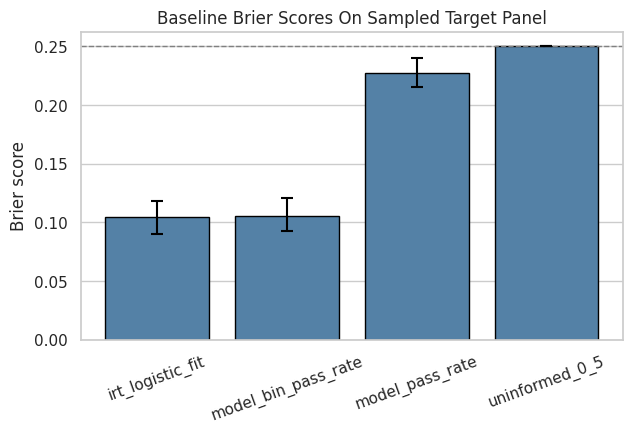

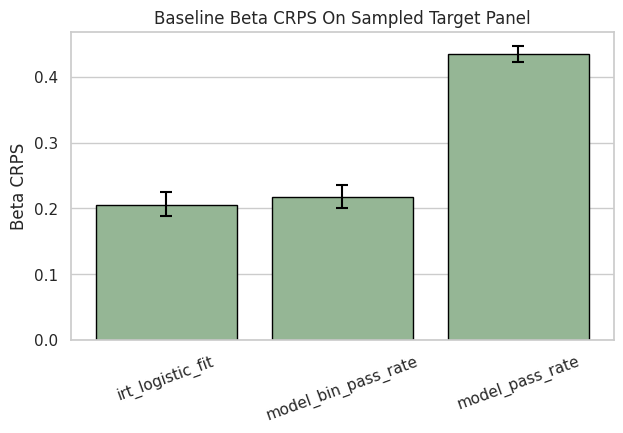

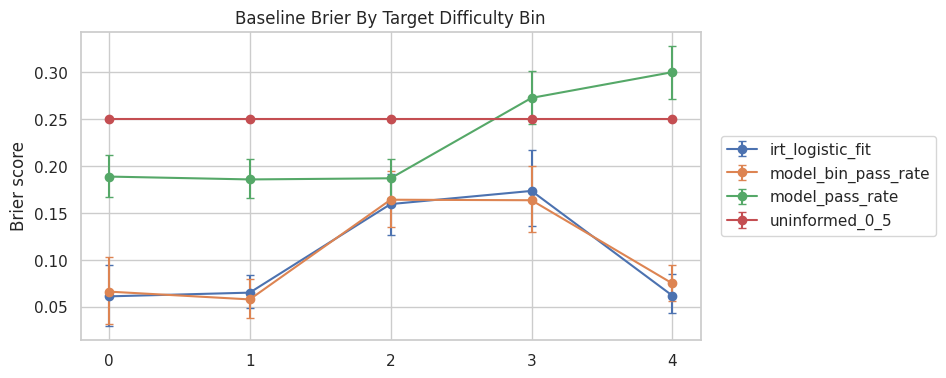

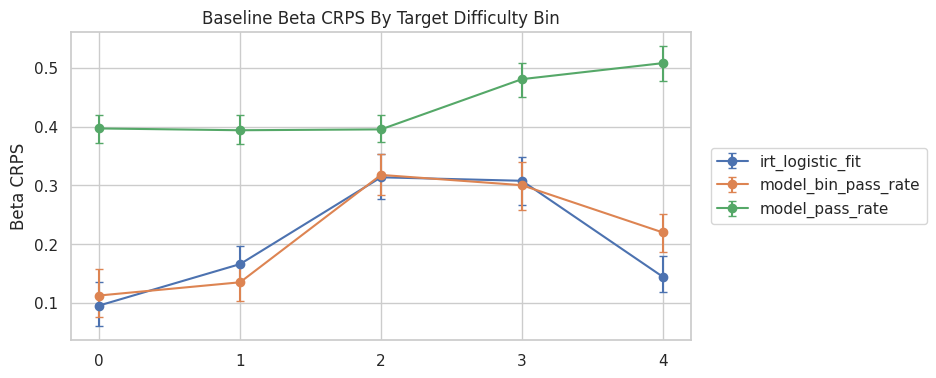

In [7]:
def add_errorbars(ax, data: pd.DataFrame, x: str, y: str, low: str, high: str, *, color: str = "black") -> None:
    for x_value, row in enumerate(data.itertuples(index=False)):
        y_value = getattr(row, y)
        low_value = getattr(row, low)
        high_value = getattr(row, high)
        if pd.isna(y_value) or pd.isna(low_value) or pd.isna(high_value):
            continue
        ax.errorbar(
            x=x_value,
            y=y_value,
            yerr=[[y_value - low_value], [high_value - y_value]],
            fmt="none",
            ecolor=color,
            elinewidth=1.5,
            capsize=4,
            capthick=1.5,
            zorder=3,
        )


def plot_metric_by_bin(scores: pd.DataFrame, metric: str, ylabel: str, title: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 4))
    for baseline_name, baseline_scores in scores.sort_values("target_bin").groupby("baseline", sort=False):
        ax.errorbar(
            baseline_scores["target_bin"],
            baseline_scores[metric],
            yerr=[
                baseline_scores[metric] - baseline_scores[f"{metric}_ci_low"],
                baseline_scores[f"{metric}_ci_high"] - baseline_scores[metric],
            ],
            marker="o",
            capsize=3,
            linewidth=1.5,
            label=baseline_name,
        )
    ax.set_xticks(range(N_BINS))
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.show()


fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=overall_scores, x="baseline", y="brier", ax=ax, color="steelblue", edgecolor="black")
add_errorbars(ax, overall_scores.reset_index(drop=True), "baseline", "brier", "brier_ci_low", "brier_ci_high")
ax.axhline(0.25, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("")
ax.set_ylabel("Brier score")
ax.set_title("Baseline Brier Scores On Sampled Target Panel")
ax.tick_params(axis="x", rotation=20)
plt.show()

crps_overall = overall_scores.dropna(subset=["crps_beta"]).sort_values("crps_beta").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=crps_overall, x="baseline", y="crps_beta", ax=ax, color="darkseagreen", edgecolor="black")
add_errorbars(ax, crps_overall, "baseline", "crps_beta", "crps_beta_ci_low", "crps_beta_ci_high")
ax.set_xlabel("")
ax.set_ylabel("Beta CRPS")
ax.set_title("Baseline Beta CRPS On Sampled Target Panel")
ax.tick_params(axis="x", rotation=20)
plt.show()

plot_metric_by_bin(by_bin_scores, "brier", "Brier score", "Baseline Brier By Target Difficulty Bin")
plot_metric_by_bin(
    by_bin_scores.dropna(subset=["crps_beta"]),
    "crps_beta",
    "Beta CRPS",
    "Baseline Beta CRPS By Target Difficulty Bin",
)


## Optional: Score Baselines On An Existing Calibration Run

This section evaluates the same baselines on the exact `(forecasted_model, target_task_id, target_bin, outcome)` cells from a run CSV, then compares them with the elicited `p50` scores. This is the most direct apples-to-apples comparator for a completed `intra_benchmark_calibration` run.

In [8]:
def find_run_csv(run_dir: Path) -> Path:
    matches = sorted(run_dir.glob("*_estimates.csv"))
    if not matches:
        raise FileNotFoundError(f"No *_estimates.csv found in {run_dir}")
    return matches[-1]


def run_panel_from_csv(run_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(find_run_csv(run_dir))
    df = valid_rows(df, last_round_only=True)
    for quantile_col in ["p25", "p50", "p75"]:
        if quantile_col not in df.columns:
            df[quantile_col] = np.nan
    cols = [
        "forecasted_model",
        "target_task_id",
        "target_task_family",
        "target_fst_minutes",
        "target_bin",
        "outcome",
        "p25",
        "p50",
        "p75",
    ]
    cols = [c for c in cols if c in df.columns]
    return df[cols].drop_duplicates(["forecasted_model", "target_task_id", "target_bin", "outcome"]).reset_index(drop=True)


if RUN_DIR.exists():
    run_panel = run_panel_from_csv(RUN_DIR)
    run_panel = add_baseline_predictions(run_panel)
    run_scores = score_baselines(run_panel, seed_offset=3)

    elicited = run_panel.dropna(subset=["p50"]).copy()
    err = elicited["p50"].astype(float) - elicited["outcome"].astype(float)
    elicited_crps = beta_crps_contributions(elicited, ("p25", "p50", "p75"))
    brier_low, brier_high = bootstrap_mean_ci(err**2, rng=np.random.default_rng(BOOTSTRAP_SEED + 10_003))
    crps_low, crps_high = bootstrap_mean_ci(elicited_crps, rng=np.random.default_rng(BOOTSTRAP_SEED + 10_004))
    elicited_score = pd.DataFrame(
        [
            {
                "baseline": "elicited_p50",
                "n": int(len(elicited)),
                "mean_prediction": float(elicited["p50"].mean()),
                "empirical_pass_rate": float(elicited["outcome"].mean()),
                "brier": float(np.mean(err**2)),
                "brier_ci_low": brier_low,
                "brier_ci_high": brier_high,
                "bias": float(np.mean(err)),
                "crps_beta": float(elicited_crps.mean()) if elicited_crps.notna().any() else np.nan,
                "crps_beta_ci_low": crps_low,
                "crps_beta_ci_high": crps_high,
            }
        ]
    )
    display(pd.concat([run_scores, elicited_score], ignore_index=True).sort_values("brier"))
else:
    print(f"RUN_DIR does not exist: {RUN_DIR}")


,baseline,n,mean_prediction,empirical_pass_rate,brier,brier_ci_low,brier_ci_high,bias,crps_beta,crps_beta_ci_low,crps_beta_ci_high
2,model_bin_pass_rate,60,0.569114,0.516667,0.072333,0.047683,0.100009,0.052447,0.182569,0.137967,0.227689
3,irt_logistic_fit,60,0.559988,0.516667,0.081983,0.049699,0.120207,0.043322,0.184402,0.141142,0.235104
4,elicited_p50,60,0.436333,0.516667,0.224473,0.164076,0.291961,-0.080333,0.303538,0.240126,0.369645
0,uninformed_0_5,60,0.500000,0.516667,0.250000,0.250000,0.250000,-0.016667,NaN,NaN,NaN
1,model_pass_rate,60,0.566857,0.516667,0.256234,0.217338,0.296849,0.050190,0.463764,0.425172,0.504680
